In [2]:

from typing import Any, Optional

import numpy as np
import tensorflow as tf
from check_shapes import check_shapes, inherit_check_shapes
import gpflow
from gpflow.base import Parameter, TensorType
from gpflow.utilities import positive
from gpflow.utilities.ops import difference_matrix, square_distance
from gpflow.kernels.base import ActiveDims, Kernel

class Stationary(Kernel):
    """
    Base class for kernels that are stationary, that is, they only depend on

        d = x - x'

    This class handles 'ard' behaviour, which stands for 'Automatic Relevance
    Determination'. This means that the kernel has one lengthscale per
    dimension, otherwise the kernel is isotropic (has a single lengthscale).
    """

    @check_shapes(
        "variance: []",
        "lengthscales: [broadcast n_active_dims]",
    )
    def __init__(
        self, variance: TensorType = 1.0, lengthscales: TensorType = 1.0, lag = 0, **kwargs: Any
    ) -> None:
        """
        :param variance: the (initial) value for the variance parameter.
        :param lengthscales: the (initial) value for the lengthscale
            parameter(s), to induce ARD behaviour this must be initialised as
            an array the same length as the number of active dimensions
            e.g. [1., 1., 1.]. If only a single value is passed, this value
            is used as the lengthscale of each dimension.
        :param kwargs: accepts `name` and `active_dims`, which is a list or
            slice of indices which controls which columns of X are used (by
            default, all columns are used).
        """
        for kwarg in kwargs:
            if kwarg not in {"name", "active_dims"}:
                raise TypeError(f"Unknown keyword argument: {kwarg}")

        super().__init__(**kwargs)
        self.variance = Parameter(variance, transform=positive())
        self.lag = Parameter(lag)
        self.lengthscales = Parameter(lengthscales, transform=positive())
        self._validate_ard_active_dims(self.lengthscales)

    @property
    def ard(self) -> bool:
        """
        Whether ARD behaviour is active.
        """
        ndims: int = self.lengthscales.shape.ndims
        return ndims > 0

    @check_shapes(
        "X: [broadcast any...]",
        "return: [any...]",
    )
    def scale(self, X: TensorType) -> TensorType:
        X_scaled = X / self.lengthscales if X is not None else X
        return X_scaled

    @inherit_check_shapes
    def K_diag(self, X: TensorType) -> tf.Tensor:
        return tf.fill(tf.shape(X)[:-1], tf.squeeze(self.variance))


class IsotropicStationary(Stationary):
    """
    Base class for isotropic stationary kernels, i.e. kernels that only
    depend on

        r = ‖x - x'‖

    Derived classes should implement one of:

        K_r2(self, r2): Returns the kernel evaluated on r² (r2), which is the
        squared scaled Euclidean distance Should operate element-wise on r2.

        K_r(self, r): Returns the kernel evaluated on r, which is the scaled
        Euclidean distance. Should operate element-wise on r.
    """

    @inherit_check_shapes
    def K(self, X: TensorType, X2: Optional[TensorType] = None) -> tf.Tensor:
        r2 = self.scaled_squared_euclid_dist(X, X2)
        return self.K_r2(r2)

    @check_shapes(
        "r2: [batch..., N]",
        "return: [batch..., N]",
    )
    def K_r2(self, r2: TensorType) -> tf.Tensor:
        if hasattr(self, "K_r"):
            # Clipping around the (single) float precision which is ~1e-45.
            r = tf.sqrt(tf.maximum(r2, 1e-36))
            return self.K_r(r)  # pylint: disable=no-member
        raise NotImplementedError

    @check_shapes(
        "X: [batch..., N, D]",
        "X2: [batch2..., N2, D]",
        "return: [batch..., N, batch2..., N2] if X2 is not None",
        "return: [batch..., N, N] if X2 is None",
    )
    def scaled_squared_euclid_dist(
        self, X: TensorType, X2: Optional[TensorType] = None
    ) -> tf.Tensor:
        """
        Returns ‖(X - X2ᵀ) / ℓ‖², i.e. the squared L₂-norm.
        """
        return square_distance(self.scale(X + self.lag), self.scale(X2))


class LaggedRBF(IsotropicStationary):
    """
    The radial basis function (RBF) or squared exponential kernel. The kernel equation is

        k(r) = σ² exp{-½ r²}

    where:
    r   is the Euclidean distance between the input points, scaled by the lengthscales parameter ℓ.
    σ²  is the variance parameter

    Functions drawn from a GP with this kernel are infinitely differentiable!
    """

    @inherit_check_shapes
    def K_r2(self, r2: TensorType) -> tf.Tensor:
        return self.variance * tf.exp(-0.5 * r2)

import numpy as np


2025-11-17 16:17:41.268070: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-17 16:17:41.353845: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-17 16:17:41.489720: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-17 16:17:41.490997: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-17 16:17:42.332004: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

[[ 50.25125628  55.27638191]
 [ 51.25628141  56.28140704]
 [ 52.26130653  57.28643216]
 [ 53.26633166  58.29145729]
 [ 54.27135678  59.29648241]
 [ 55.27638191  60.30150754]
 [ 56.28140704  61.30653266]
 [ 57.28643216  62.31155779]
 [ 58.29145729  63.31658291]
 [ 59.29648241  64.32160804]
 [ 60.30150754  65.32663317]
 [ 61.30653266  66.33165829]
 [ 62.31155779  67.33668342]
 [ 63.31658291  68.34170854]
 [ 64.32160804  69.34673367]
 [ 65.32663317  70.35175879]
 [ 66.33165829  71.35678392]
 [ 67.33668342  72.36180905]
 [ 68.34170854  73.36683417]
 [ 69.34673367  74.3718593 ]
 [ 70.35175879  75.37688442]
 [ 71.35678392  76.38190955]
 [ 72.36180905  77.38693467]
 [ 73.36683417  78.3919598 ]
 [ 74.3718593   79.39698492]
 [ 75.37688442  80.40201005]
 [ 76.38190955  81.40703518]
 [ 77.38693467  82.4120603 ]
 [ 78.3919598   83.41708543]
 [ 79.39698492  84.42211055]
 [ 80.40201005  85.42713568]
 [ 81.40703518  86.4321608 ]
 [ 82.4120603   87.43718593]
 [ 83.41708543  88.44221106]
 [ 84.42211055

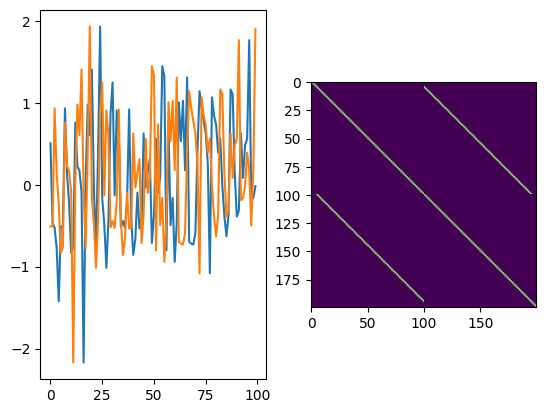

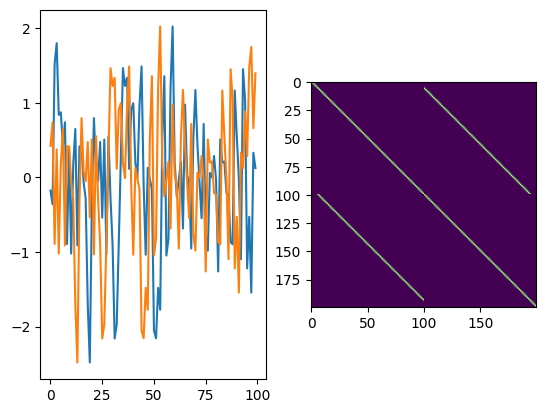

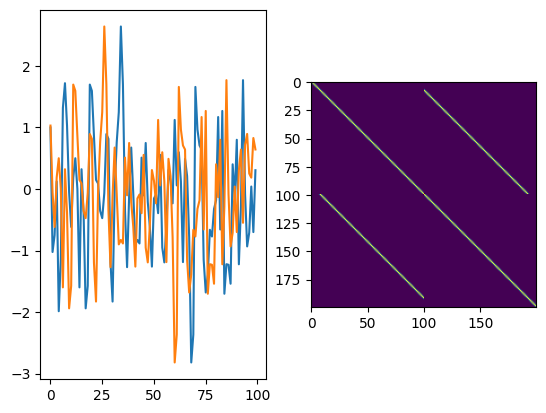

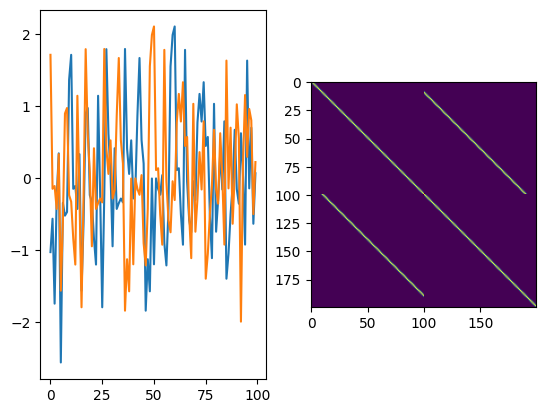

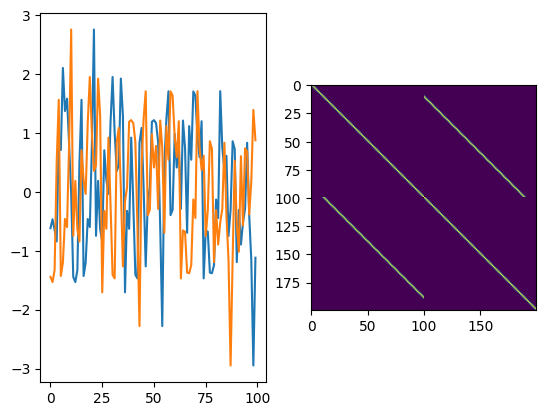

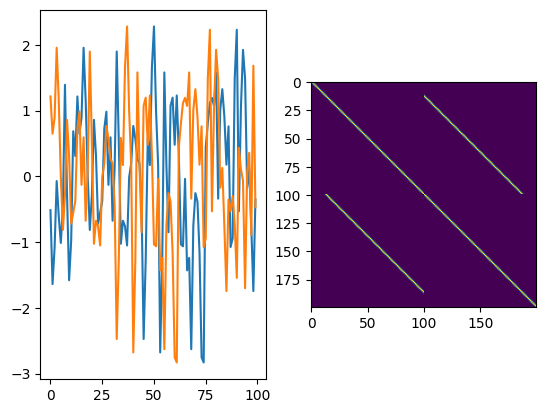

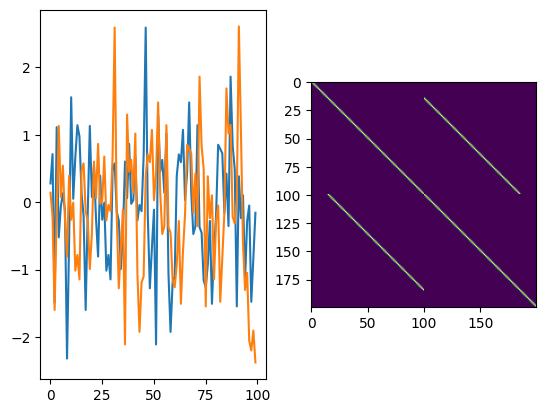

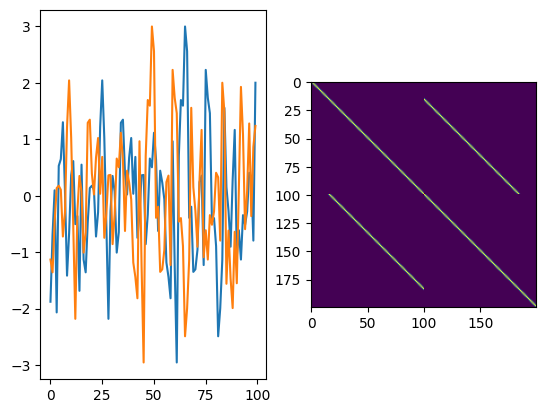

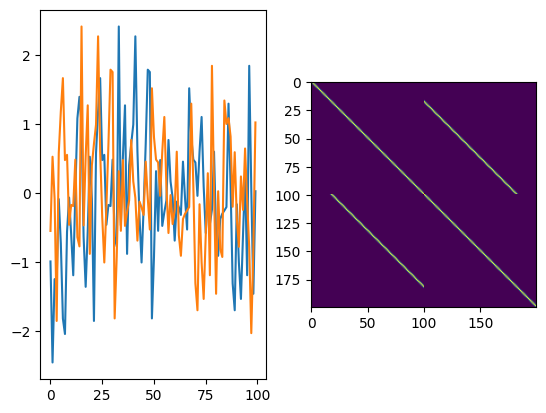

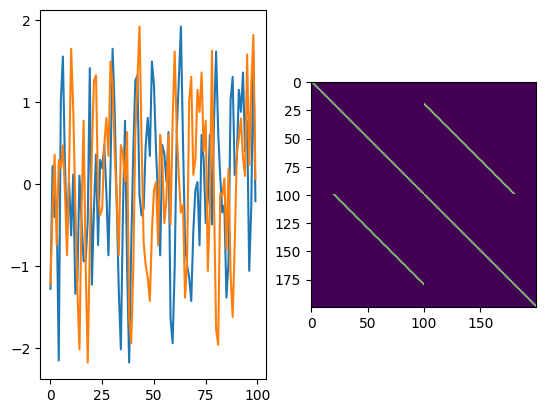

In [9]:
import matplotlib.pyplot as plt
import scipy.stats as sssquare_distance
import scipy.signal as signal
X = np.linspace(0, 200, 200).reshape(-1, 1)

rbf = gpflow.kernels.RBF()
y = np.random.multivariate_normal(np.zeros_like(X.flatten()), rbf(X))

start, stop = 50, 150
X1 = np.hstack((X[50:150], X[55:155]))
print(X1)
y1 = y[50:150].reshape(-1, 1)

for i in np.linspace(5, 20, 10, dtype=int):
    fig, ax = plt.subplots(1, 2)
    a, b = 50 + i, 150 + i
    X2 = np.hstack((X[a:b], X[a + 5:b + 5]))
    y2 = y[a:b].reshape(-1, 1)
    rbf = LaggedRBF(lag=i)
    #rbf = gpflow.kernels.RBF()

    yt = np.concatenate((y1, y2))
    Xt = np.concatenate((X1, X2))
    sample = np.random.multivariate_normal(np.zeros(Xt[:,0].flatten().shape), rbf(Xt))
    
    ax[0].plot(sample[:len(y1)])
    ax[0].plot(sample[len(y1):])
    ax[1].imshow(rbf(Xt))
    plt.show()
